In [1]:
import sys
sys.path.append('../src')
import importlib
import hsc_downloader
importlib.reload(hsc_downloader)
from hsc_downloader import download_hsc_cutout

hdul = download_hsc_cutout(ra_center=150.106, dec_center=2.22092, size_arcsec=108)
hdul.info()

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      20   ()      
  1                1 ImageHDU        44   (643, 644)   float32   
  2                1 ImageHDU         5   ()      
  3                1 ImageHDU         5   ()      


In [2]:
import os
print(repr(os.environ.get('SSP_PDR_USR')))

'yawpa'


In [3]:
import sys
sys.path.append('../src')
import importlib
import hsc_downloader
importlib.reload(hsc_downloader)
from hsc_downloader import download_hsc_cutout

hdul = download_hsc_cutout(ra_center=150.106, dec_center=2.22092, size_arcsec=108)
hdul.info()

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      20   ()      
  1                1 ImageHDU        44   (643, 644)   float32   
  2                1 ImageHDU         5   ()      
  3                1 ImageHDU         5   ()      


(644, 643) >f4
-0.038912345 300.60297 0.006947108


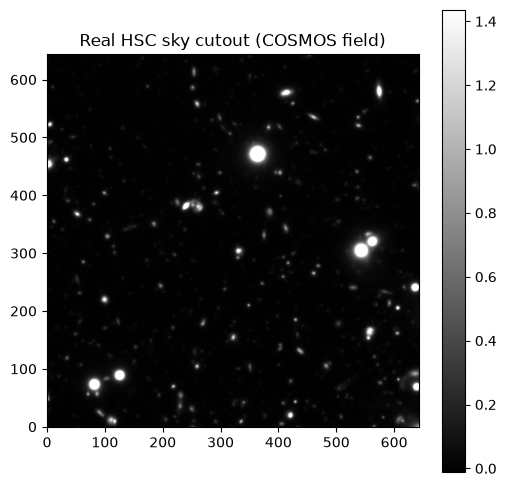

In [4]:
import numpy as np
import matplotlib.pyplot as plt
image_data = hdul[1].data
print(image_data.shape, image_data.dtype)
print(np.nanmin(image_data), np.nanmax(image_data), np.nanmedian(image_data))

plt.figure(figsize=(6, 6))
plt.imshow(image_data, cmap='gray', origin='lower',
           vmin=np.nanpercentile(image_data, 5), vmax=np.nanpercentile(image_data, 99.5))
plt.colorbar()
plt.title("Real HSC sky cutout (COSMOS field)")
plt.show()

In [5]:
header = hdul[1].header
print(repr(header))

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  643                                                  
NAXIS2  =                  644                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
COMMENT                                                                         
COMMENT                                                                         
COMMENT                                                                         
COMMENT                                                                         
COMMENT                                                                         
COMMENT                     

In [6]:
pixel_scale_arcsec = pixel_scales[0].to(u.arcsec).value
print(pixel_scale_arcsec)

NameError: name 'pixel_scales' is not defined

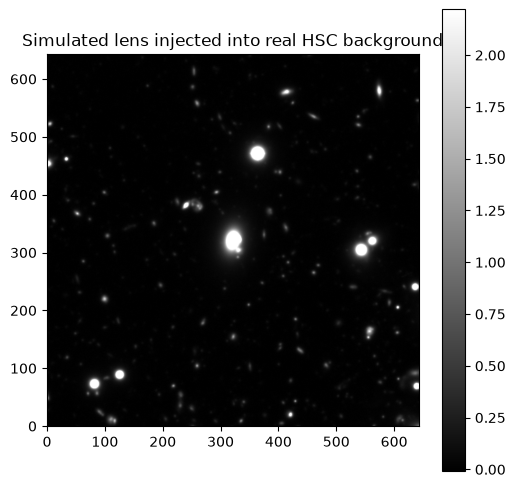

In [ ]:
importlib.reload(lens_injector) if 'lens_injector' in dir() else None
import lens_injector
importlib.reload(lens_injector)
from lens_injector import inject_lens_into_background

result_injected = inject_lens_into_background(image_data, pixel_scale=pixel_scale_arcsec, is_lens=True, seed=500)

plt.figure(figsize=(6, 6))
plt.imshow(result_injected['image'], cmap='gray', origin='lower',
           vmin=np.nanpercentile(result_injected['image'], 5),
           vmax=np.nanpercentile(result_injected['image'], 99.5))
plt.colorbar()
plt.title("Simulated lens injected into real HSC background")
plt.show()

In [7]:
import lens_injector
importlib.reload(lens_injector)
from lens_injector import inject_lens_into_background

image_data = hdul[1].data

result_injected = inject_lens_into_background(image_data, pixel_scale=pixel_scale_arcsec, is_lens=True, seed=500)

plt.figure(figsize=(6, 6))
plt.imshow(result_injected['image'], cmap='gray', origin='lower',
           vmin=np.nanpercentile(result_injected['image'], 5),
           vmax=np.nanpercentile(result_injected['image'], 99.5))
plt.colorbar()
plt.title("Simulated lens injected into real HSC background")
plt.show()

NameError: name 'pixel_scale_arcsec' is not defined

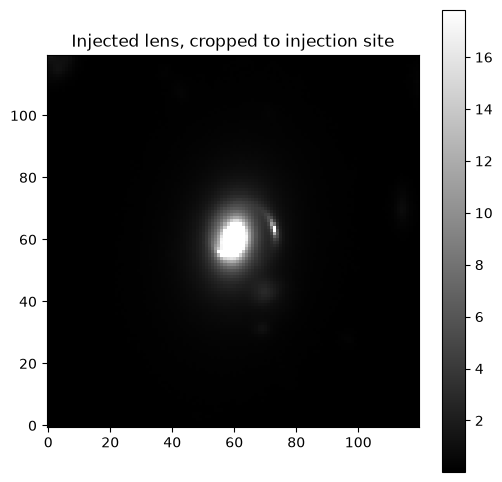

In [ ]:
center = numPix = min(image_data.shape)
crop_size = 60
c = center // 2

cutout_injected = result_injected['image'][c - crop_size:c + crop_size, c - crop_size:c + crop_size]

plt.figure(figsize=(6, 6))
plt.imshow(cutout_injected, cmap='gray', origin='lower',
           vmin=np.nanpercentile(cutout_injected, 5), vmax=np.nanpercentile(cutout_injected, 99.5))
plt.colorbar()
plt.title("Injected lens, cropped to injection site")
plt.show()

In [ ]:
from photutils.detection import DAOStarFinder
from astropy.stats import sigma_clipped_stats

mean, median, std = sigma_clipped_stats(image_data, sigma=3.0)
print(mean, median, std)

daofind = DAOStarFinder(fwhm=5.0, threshold=10.0 * std)
sources = daofind(image_data - median)
sources.sort('flux', reverse=True)
print(sources[:10])

0.007748151 0.0054404913 0.014110594
 id     x_centroid         y_centroid     ...    mag         daofind_mag    
--- ------------------ ------------------ ... ---------- -------------------
173 363.94213295985566  471.6234241832776 ...  -9.792427  -8.111530870553787
 39  82.07203365947835  73.13000744501672 ...  -8.394996  -7.214423236880067
123  543.5600143388228  304.7326286527256 ...  -8.306992  -7.071030698372343
 47  125.6057163498196   88.9721791193052 ...  -8.095858  -7.224664105075148
101   636.488777528044 240.86079561170638 ... -7.2073145  -6.609101216656118
 37  639.2157958069577  69.16697545943794 ... -7.0547695  -6.497752659572065
125  562.2949055673438 320.16967409142217 ... -6.6036706  -5.321213700418143
145  240.4642174502219 382.14213768878045 ...  -5.700915  -4.543669840265837
169 1.8311154305388886 453.99127093117403 ... -5.3628964  -4.280030003058182
203 414.39599604368124  578.0197928494972 ... -4.9600554 -3.0129618048400753


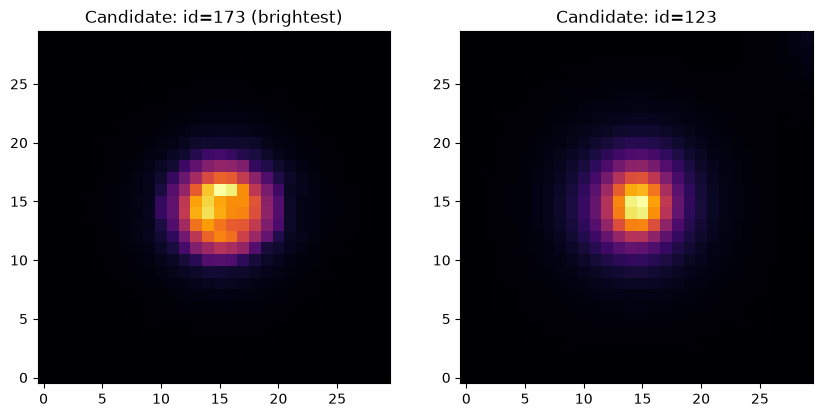

id=173 max: 300.60297
id=123 max: 84.710175


In [ ]:
def extract_stamp(image, x_center, y_center, half_size=15):
    x_int, y_int = int(round(x_center)), int(round(y_center))
    return image[y_int - half_size:y_int + half_size, x_int - half_size:x_int + half_size]

stamp_173 = extract_stamp(image_data, 363.94, 471.62)
stamp_123 = extract_stamp(image_data, 543.56, 304.73)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(stamp_173, cmap='inferno', origin='lower')
axes[0].set_title("Candidate: id=173 (brightest)")
axes[1].imshow(stamp_123, cmap='inferno', origin='lower')
axes[1].set_title("Candidate: id=123")
plt.show()

print("id=173 max:", stamp_173.max())
print("id=123 max:", stamp_123.max())

In [ ]:
print("id=173 pixels within 1% of max:", (stamp_173 > 0.99 * stamp_173.max()).sum())
print("id=123 pixels within 1% of max:", (stamp_123 > 0.99 * stamp_123.max()).sum())

id=173 pixels within 1% of max: 1
id=123 pixels within 1% of max: 1


(31, 31)
1.0


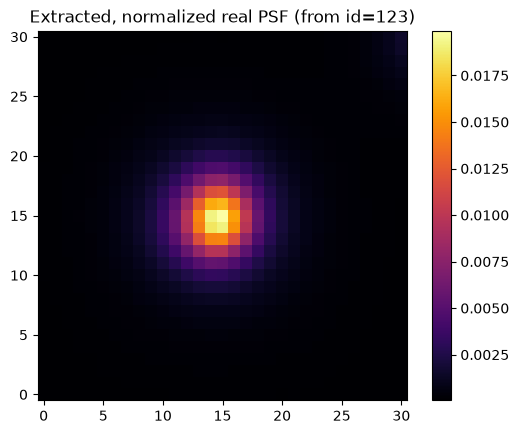

In [ ]:
def extract_stamp_odd(image, x_center, y_center, half_size=15):
    x_int, y_int = int(round(x_center)), int(round(y_center))
    return image[y_int - half_size:y_int + half_size + 1, x_int - half_size:x_int + half_size + 1]

psf_stamp = extract_stamp_odd(image_data, 543.56, 304.73, half_size=15)
print(psf_stamp.shape)

psf_stamp_normalized = psf_stamp / psf_stamp.sum()
print(psf_stamp_normalized.sum())

plt.imshow(psf_stamp_normalized, cmap='inferno', origin='lower')
plt.colorbar()
plt.title("Extracted, normalized real PSF (from id=123)")
plt.show()

In [ ]:
from lenstronomy.SimulationAPI.sim_api import SimAPI
kwargs_data_pixel_psf = {
    'pixel_scale': pixel_scale_arcsec,
    'exposure_time': 100,
    'magnitude_zero_point': 25.0,
    'sky_brightness': 30.0,
    'read_noise': 0.001,
    'ccd_gain': 2.5,
    'psf_type': 'PIXEL',
    'kernel_point_source': psf_stamp_normalized
}

numPix_test = min(image_data.shape)

sim_api_pixel = SimAPI(numpix=numPix_test, kwargs_single_band=kwargs_data_pixel_psf, kwargs_model={
    'lens_model_list': ['SIE'],
    'source_light_model_list': ['SERSIC_ELLIPSE'],
    'lens_light_model_list': ['SERSIC_ELLIPSE']
})

image_model_pixel = sim_api_pixel.image_model_class()
signal_real_psf = image_model_pixel.image(
    kwargs_lens=[{'theta_E': 1.2, 'e1': 0.1, 'e2': 0.05, 'center_x': 0.0, 'center_y': 0.0}],
    kwargs_source=[{'amp': 120, 'R_sersic': 0.3, 'n_sersic': 1.5, 'e1': 0.05, 'e2': -0.05, 'center_x': 0.5, 'center_y': 0.5}],
    kwargs_lens_light=[{'amp': 300, 'R_sersic': 0.8, 'n_sersic': 4, 'e1': 0.05, 'e2': -0.02, 'center_x': 0.0, 'center_y': 0.0}]
)

plt.figure(figsize=(6, 6))
plt.imshow(signal_real_psf, cmap='inferno', origin='lower', vmax=np.percentile(signal_real_psf, 99.5))
plt.colorbar()
plt.title("Simulated signal, convolved with REAL extracted PSF")
plt.show()

NameError: name 'pixel_scale_arcsec' is not defined

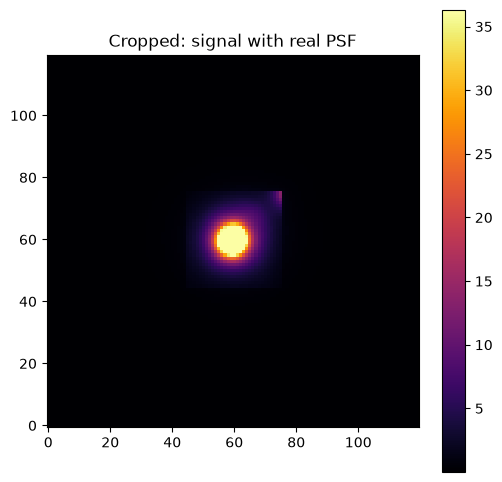

In [ ]:
c = numPix_test // 2
crop_size = 60
signal_cropped = signal_real_psf[c - crop_size:c + crop_size, c - crop_size:c + crop_size]

plt.figure(figsize=(6, 6))
plt.imshow(signal_cropped, cmap='inferno', origin='lower', vmax=np.percentile(signal_cropped, 99.5))
plt.colorbar()
plt.title("Cropped: signal with real PSF")
plt.show()

In [ ]:
print(psf_stamp.shape)
print(psf_stamp_normalized.sum())

(31, 31)
1.0


In [ ]:
peak_y, peak_x = np.unravel_index(np.argmax(signal_real_psf), signal_real_psf.shape)
print("Peak location:", peak_x, peak_y)
print("Expected center:", numPix_test // 2, numPix_test // 2)

Peak location: 321 321
Expected center: 321 321


In [8]:
plt.figure(figsize=(6, 6))
plt.imshow(signal_cropped, cmap='inferno', origin='lower', vmax=np.percentile(signal_cropped, 90))
plt.colorbar()
plt.title("Same crop, more aggressive contrast stretch")
plt.show()

NameError: name 'signal_cropped' is not defined

<Figure size 600x600 with 0 Axes>

In [9]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(6, 6))
plt.imshow(signal_cropped, cmap='inferno', origin='lower', norm=LogNorm(vmin=signal_cropped.max()*1e-4, vmax=signal_cropped.max()))
plt.colorbar()
plt.title("Cropped signal, log stretch")
plt.show()

NameError: name 'signal_cropped' is not defined

<Figure size 600x600 with 0 Axes>

In [10]:
print("Center value:", psf_stamp_normalized[15, 15])
print("Edge values (top row):", psf_stamp_normalized[0, :])
print("Max edge value:", psf_stamp_normalized[0, :].max(), psf_stamp_normalized[-1, :].max())

NameError: name 'psf_stamp_normalized' is not defined

In [11]:
from astropy.stats import sigma_clipped_stats

stamp_mean, stamp_median, stamp_std = sigma_clipped_stats(psf_stamp, sigma=3.0)
print("Local background estimate:", stamp_median)

psf_stamp_bg_subtracted = psf_stamp - stamp_median
psf_stamp_bg_subtracted[psf_stamp_bg_subtracted < 0] = 0

psf_stamp_normalized_v2 = psf_stamp_bg_subtracted / psf_stamp_bg_subtracted.sum()
print(psf_stamp_normalized_v2.sum())
print("New edge max:", psf_stamp_normalized_v2[0, :].max(), psf_stamp_normalized_v2[-1, :].max())

NameError: name 'psf_stamp' is not defined

In [12]:
psf_stamp_bg_subtracted_v2 = psf_stamp - median
psf_stamp_bg_subtracted_v2[psf_stamp_bg_subtracted_v2 < 0] = 0

psf_stamp_normalized_v3 = psf_stamp_bg_subtracted_v2 / psf_stamp_bg_subtracted_v2.sum()
print(psf_stamp_normalized_v3.sum())
print("New edge max:", psf_stamp_normalized_v3[0, :].max(), psf_stamp_normalized_v3[-1, :].max())

NameError: name 'psf_stamp' is not defined

In [13]:
from astropy.stats import sigma_clipped_stats
mean, median, std = sigma_clipped_stats(image_data, sigma=3.0)
print(median)

0.0054404913


In [14]:
plt.figure(figsize=(6, 6))
plt.imshow(psf_stamp, cmap='inferno', origin='lower', norm=LogNorm(vmin=psf_stamp.max()*1e-3, vmax=psf_stamp.max()))
plt.colorbar()
plt.title("Raw PSF stamp, log stretch — checking for contamination")
plt.show()

NameError: name 'psf_stamp' is not defined

<Figure size 600x600 with 0 Axes>

In [15]:
stamp_173_odd = extract_stamp_odd(image_data, 363.94, 471.62, half_size=15)

plt.figure(figsize=(6, 6))
plt.imshow(stamp_173_odd, cmap='inferno', origin='lower', norm=LogNorm(vmin=stamp_173_odd.max()*1e-3, vmax=stamp_173_odd.max()))
plt.colorbar()
plt.title("id=173 stamp, log stretch — checking for contamination")
plt.show()

NameError: name 'extract_stamp_odd' is not defined

In [16]:
psf_stamp_173 = stamp_173_odd - median
psf_stamp_173[psf_stamp_173 < 0] = 0
psf_stamp_173_normalized = psf_stamp_173 / psf_stamp_173.sum()

print(psf_stamp_173_normalized.sum())
print("Edge maxes:", psf_stamp_173_normalized[0, :].max(), psf_stamp_173_normalized[-1, :].max())
print("Center value:", psf_stamp_173_normalized[15, 15])

NameError: name 'stamp_173_odd' is not defined

In [17]:
kwargs_data_pixel_psf_v2 = {
    'pixel_scale': pixel_scale_arcsec,
    'exposure_time': 100,
    'magnitude_zero_point': 25.0,
    'sky_brightness': 30.0,
    'read_noise': 0.001,
    'ccd_gain': 2.5,
    'psf_type': 'PIXEL',
    'kernel_point_source': psf_stamp_173_normalized
}

sim_api_pixel_v2 = SimAPI(numpix=numPix_test, kwargs_single_band=kwargs_data_pixel_psf_v2, kwargs_model={
    'lens_model_list': ['SIE'],
    'source_light_model_list': ['SERSIC_ELLIPSE'],
    'lens_light_model_list': ['SERSIC_ELLIPSE']
})

image_model_pixel_v2 = sim_api_pixel_v2.image_model_class()
signal_real_psf_v2 = image_model_pixel_v2.image(
    kwargs_lens=[{'theta_E': 1.2, 'e1': 0.1, 'e2': 0.05, 'center_x': 0.0, 'center_y': 0.0}],
    kwargs_source=[{'amp': 120, 'R_sersic': 0.3, 'n_sersic': 1.5, 'e1': 0.05, 'e2': -0.05, 'center_x': 0.5, 'center_y': 0.5}],
    kwargs_lens_light=[{'amp': 300, 'R_sersic': 0.8, 'n_sersic': 4, 'e1': 0.05, 'e2': -0.02, 'center_x': 0.0, 'center_y': 0.0}]
)

c = numPix_test // 2
crop_size = 60
signal_cropped_v2 = signal_real_psf_v2[c - crop_size:c + crop_size, c - crop_size:c + crop_size]

plt.figure(figsize=(6, 6))
plt.imshow(signal_cropped_v2, cmap='inferno', origin='lower', norm=LogNorm(vmin=signal_cropped_v2.max()*1e-4, vmax=signal_cropped_v2.max()))
plt.colorbar()
plt.title("Cropped signal, corrected clean PSF, log stretch")
plt.show()

NameError: name 'pixel_scale_arcsec' is not defined

In [18]:
from astropy.convolution import convolve_fft

kwargs_data_raw = {
    'pixel_scale': pixel_scale_arcsec,
    'exposure_time': 100,
    'magnitude_zero_point': 25.0,
    'sky_brightness': 30.0,
    'read_noise': 0.001,
    'ccd_gain': 2.5,
    'psf_type': 'NONE'
}

sim_api_raw = SimAPI(numpix=numPix_test, kwargs_single_band=kwargs_data_raw, kwargs_model={
    'lens_model_list': ['SIE'],
    'source_light_model_list': ['SERSIC_ELLIPSE'],
    'lens_light_model_list': ['SERSIC_ELLIPSE']
})

image_model_raw = sim_api_raw.image_model_class()
signal_raw = image_model_raw.image(
    kwargs_lens=[{'theta_E': 1.2, 'e1': 0.1, 'e2': 0.05, 'center_x': 0.0, 'center_y': 0.0}],
    kwargs_source=[{'amp': 120, 'R_sersic': 0.3, 'n_sersic': 1.5, 'e1': 0.05, 'e2': -0.05, 'center_x': 0.5, 'center_y': 0.5}],
    kwargs_lens_light=[{'amp': 300, 'R_sersic': 0.8, 'n_sersic': 4, 'e1': 0.05, 'e2': -0.02, 'center_x': 0.0, 'center_y': 0.0}]
)

signal_manually_convolved = convolve_fft(signal_raw, psf_stamp_173_normalized, normalize_kernel=False)

signal_cropped_v3 = signal_manually_convolved[c - crop_size:c + crop_size, c - crop_size:c + crop_size]
plt.figure(figsize=(6, 6))
plt.imshow(signal_cropped_v3, cmap='inferno', origin='lower', norm=LogNorm(vmin=signal_cropped_v3.max()*1e-4, vmax=signal_cropped_v3.max()))
plt.colorbar()
plt.title("Manually convolved with astropy, log stretch")
plt.show()

NameError: name 'pixel_scale_arcsec' is not defined

In [19]:
signal_raw_cropped = signal_raw[c - crop_size:c + crop_size, c - crop_size:c + crop_size]

plt.figure(figsize=(6, 6))
plt.imshow(signal_raw_cropped, cmap='inferno', origin='lower', norm=LogNorm(vmin=signal_raw_cropped.max()*1e-4, vmax=signal_raw_cropped.max()))
plt.colorbar()
plt.title("RAW unconvolved signal, log stretch")
plt.show()

NameError: name 'signal_raw' is not defined

In [20]:
from astropy.modeling import models, fitting

y_grid, x_grid = np.mgrid[0:31, 0:31]

moffat_init = models.Moffat2D(amplitude=psf_stamp_173.max(), x_0=15, y_0=15, gamma=3.0, alpha=2.5)

fitter = fitting.LevMarLSQFitter()
moffat_fit = fitter(moffat_init, x_grid, y_grid, psf_stamp_173)

print(moffat_fit)

NameError: name 'psf_stamp_173' is not defined

In [21]:
print(fitter.fit_info['message'])

NameError: name 'fitter' is not defined

In [22]:
moffat_init_v3 = models.Moffat2D(
    amplitude=psf_stamp_173.max(), x_0=15, y_0=15, gamma=3.0, alpha=2.5,
    bounds={'gamma': (0.5, 15), 'alpha': (0.3, 8.0), 'amplitude': (0, psf_stamp_173.max() * 2)}
)
moffat_fit_v3 = fitter(moffat_init_v3, x_grid, y_grid, psf_stamp_173)
print(moffat_fit_v3)
print(fitter.fit_info['message'])

model_image = moffat_fit_v3(x_grid, y_grid)
residual = psf_stamp_173 - model_image

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(psf_stamp_173, cmap='inferno', origin='lower')
axes[0].set_title("Real data")
axes[1].imshow(model_image, cmap='inferno', origin='lower')
axes[1].set_title("Fitted Moffat model")
im = axes[2].imshow(residual, cmap='RdBu_r', origin='lower', vmin=-10, vmax=10)
axes[2].set_title("Residual (data - model)")
plt.colorbar(im, ax=axes[2])
plt.show()

print("Residual std:", residual.std())
print("Residual max abs:", np.abs(residual).max())

NameError: name 'psf_stamp_173' is not defined

In [23]:
import sys
sys.path.append('../src')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
from astropy.modeling import models, fitting
from lenstronomy.SimulationAPI.sim_api import SimAPI

import hsc_downloader
from hsc_downloader import download_hsc_cutout

hdul = download_hsc_cutout(ra_center=150.106, dec_center=2.22092, size_arcsec=108)
image_data = hdul[1].data

header = hdul[1].header
wcs = WCS(header)
pixel_scales = wcs.proj_plane_pixel_scales()
pixel_scale_arcsec = pixel_scales[0].to(u.arcsec).value if False else pixel_scales[0].value * 3600

mean, median, std = sigma_clipped_stats(image_data, sigma=3.0)

def extract_stamp_odd(image, x_center, y_center, half_size=15):
    x_int, y_int = int(round(x_center)), int(round(y_center))
    return image[y_int - half_size:y_int + half_size + 1, x_int - half_size:x_int + half_size + 1]

stamp_173_odd = extract_stamp_odd(image_data, 363.94, 471.62, half_size=15)
psf_stamp_173 = stamp_173_odd - median

print("Pixel scale:", pixel_scale_arcsec)
print("Background median:", median)
print("Stamp shape:", psf_stamp_173.shape)

Pixel scale: 0.1679999999999004
Background median: 0.0054404913
Stamp shape: (31, 31)


Model: Moffat2D
Inputs: ('x', 'y')
Outputs: ('z',)
Model set size: 1
Parameters:
        amplitude             x_0               y_0               gamma        alpha
    ------------------ ----------------- ------------------ ------------------ -----
    297.63527816015915 15.14264117001535 14.478896774173453 10.366114498569342   8.0
The relative error between two consecutive iterates is at most 0.000000


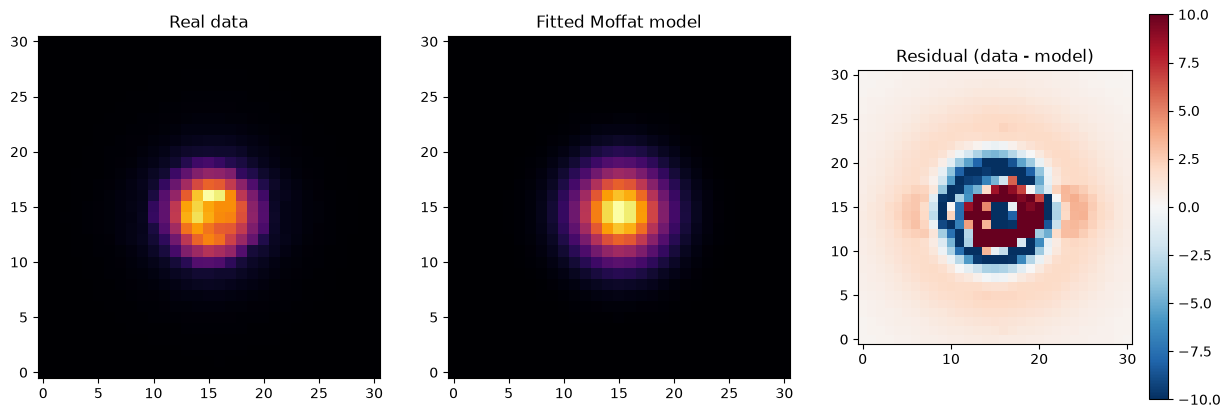

Residual std: 6.45694913203025
Residual max abs: 52.997902948150966


In [24]:
y_grid, x_grid = np.mgrid[0:31, 0:31]

fitter = fitting.LevMarLSQFitter()

moffat_init_v3 = models.Moffat2D(
    amplitude=psf_stamp_173.max(), x_0=15, y_0=15, gamma=3.0, alpha=2.5,
    bounds={'gamma': (0.5, 15), 'alpha': (0.3, 8.0), 'amplitude': (0, psf_stamp_173.max() * 2)}
)
moffat_fit_v3 = fitter(moffat_init_v3, x_grid, y_grid, psf_stamp_173)
print(moffat_fit_v3)
print(fitter.fit_info['message'])

model_image = moffat_fit_v3(x_grid, y_grid)
residual = psf_stamp_173 - model_image

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(psf_stamp_173, cmap='inferno', origin='lower')
axes[0].set_title("Real data")
axes[1].imshow(model_image, cmap='inferno', origin='lower')
axes[1].set_title("Fitted Moffat model")
im = axes[2].imshow(residual, cmap='RdBu_r', origin='lower', vmin=-10, vmax=10)
axes[2].set_title("Residual (data - model)")
plt.colorbar(im, ax=axes[2])
plt.show()

print("Residual std:", residual.std())
print("Residual max abs:", np.abs(residual).max())

In [25]:
from photutils.detection import DAOStarFinder

daofind = DAOStarFinder(fwhm=5.0, threshold=10.0 * std)
sources = daofind(image_data - median)
sources.sort('flux', reverse=True)
print(sources[:15])

 id     x_centroid         y_centroid     ...    mag         daofind_mag    
--- ------------------ ------------------ ... ---------- -------------------
173 363.94213295985566  471.6234241832776 ...  -9.792427  -8.111530870553787
 39  82.07203365947835  73.13000744501672 ...  -8.394996  -7.214423236880067
123  543.5600143388228  304.7326286527256 ...  -8.306992  -7.071030698372343
 47  125.6057163498196   88.9721791193052 ...  -8.095858  -7.224664105075148
101   636.488777528044 240.86079561170638 ... -7.2073145  -6.609101216656118
 37  639.2157958069577  69.16697545943794 ... -7.0547695  -6.497752659572065
125  562.2949055673438 320.16967409142217 ... -6.6036706  -5.321213700418143
145  240.4642174502219 382.14213768878045 ...  -5.700915  -4.543669840265837
169 1.8311154305388886 453.99127093117403 ... -5.3628964  -4.280030003058182
203 414.39599604368124  578.0197928494972 ... -4.9600554 -3.0129618048400753
170  33.50012986974307  461.8730295834945 ... -4.9115453  -4.301686248760051

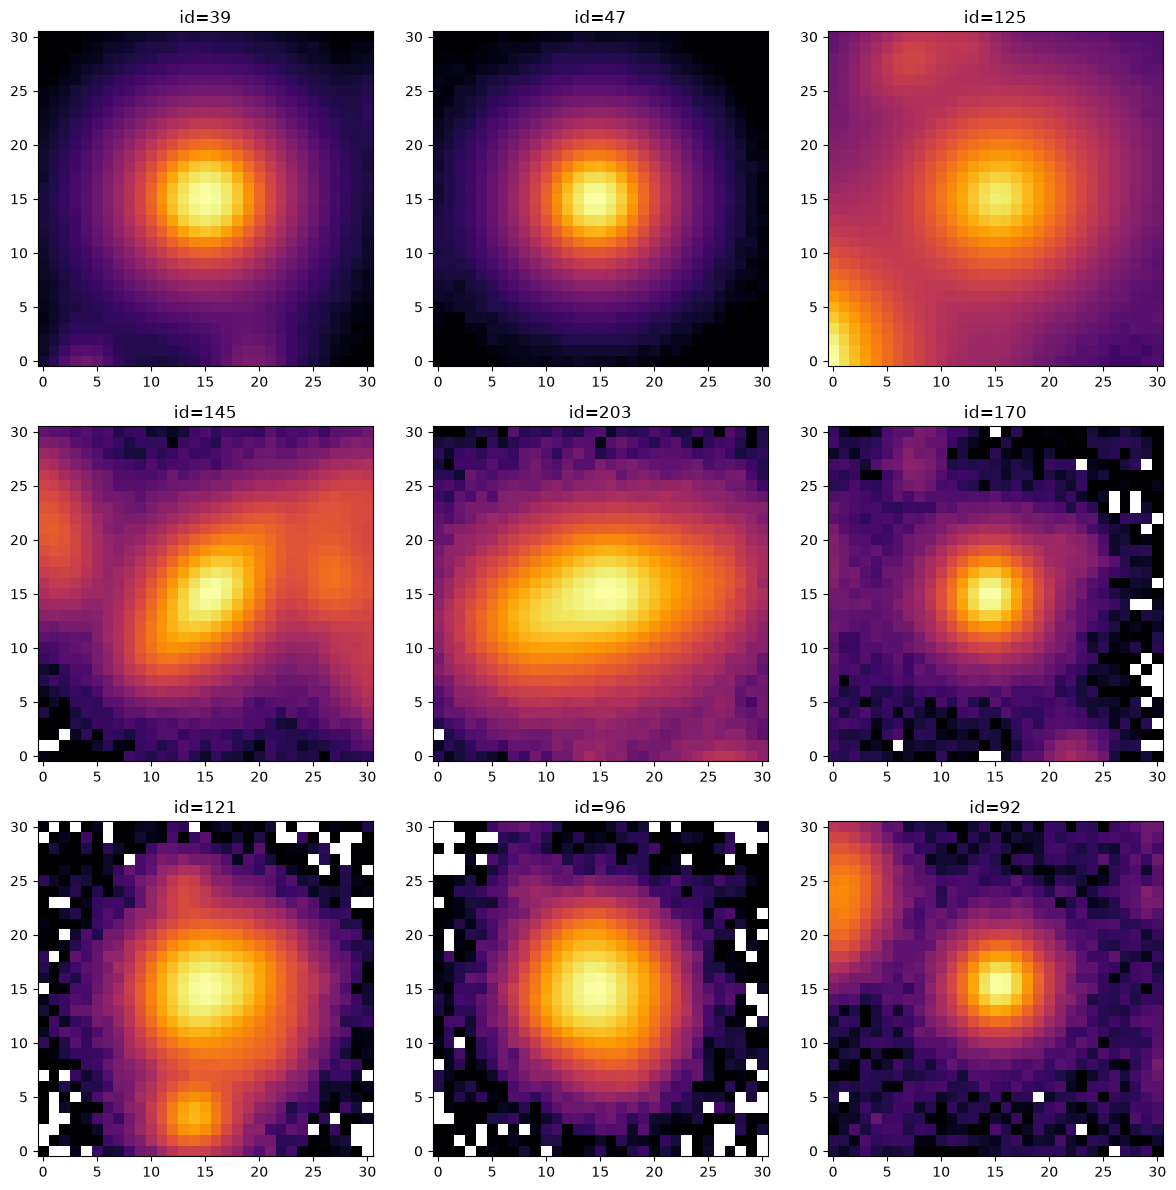

In [26]:
candidates = {
    39: (82.07, 73.13), 47: (125.61, 88.97), 125: (562.29, 320.17),
    145: (240.46, 382.14), 203: (414.40, 578.02), 170: (33.50, 461.87),
    121: (331.06, 304.04), 96: (99.53, 219.92), 92: (606.36, 205.45)
}

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
stamps = {}
for ax, (cid, (cx, cy)) in zip(axes.flat, candidates.items()):
    stamp = extract_stamp_odd(image_data, cx, cy, half_size=15)
    stamps[cid] = stamp
    ax.imshow(stamp, cmap='inferno', origin='lower', norm=LogNorm(vmin=max(stamp.max()*1e-3, 0.01), vmax=stamp.max()))
    ax.set_title(f"id={cid}")
plt.tight_layout()
plt.show()

In [27]:
for cid in [170, 96, 92]:
    print(f"id={cid}: NaNs={np.isnan(stamps[cid]).any()}, max={stamps[cid].max()}, min={stamps[cid].min()}")

id=170: NaNs=False, max=5.543298721313477, min=-0.008919193409383297
id=96: NaNs=False, max=1.7813843488693237, min=-0.018488915637135506
id=92: NaNs=False, max=3.323800563812256, min=-0.0030030403286218643


In [28]:
from scipy.ndimage import shift

def extract_and_align_stamp(image, x_center, y_center, half_size=15):
    x_int, y_int = int(round(x_center)), int(round(y_center))
    stamp = image[y_int - half_size - 2:y_int + half_size + 3, x_int - half_size - 2:x_int + half_size + 3].astype(np.float64)

    frac_x = x_center - x_int
    frac_y = y_center - y_int

    aligned = shift(stamp, shift=(-frac_y, -frac_x), order=3, mode='nearest')

    return aligned[2:-2, 2:-2]

star_coords = {173: (363.94, 471.62), 39: (82.07, 73.13), 47: (125.61, 88.97)}
aligned_stamps = {}
for cid, (cx, cy) in star_coords.items():
    aligned_stamps[cid] = extract_and_align_stamp(image_data, cx, cy, half_size=15)
    print(cid, aligned_stamps[cid].shape)

173 (31, 31)
39 (31, 31)
47 (31, 31)


Sum: 0.9999999999999998
Edge maxes: 4.4281509556189024e-05 9.233157331763436e-06


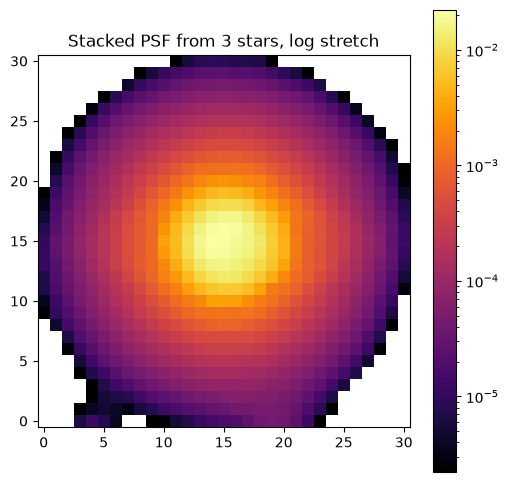

In [29]:
bg_subtracted_stamps = []
for cid, stamp in aligned_stamps.items():
    local_median = np.median(stamp[:3, :].flatten().tolist() + stamp[-3:, :].flatten().tolist() +
                               stamp[:, :3].flatten().tolist() + stamp[:, -3:].flatten().tolist())
    bg_subtracted_stamps.append(stamp - local_median)

stacked_psf = np.mean(bg_subtracted_stamps, axis=0)
stacked_psf[stacked_psf < 0] = 0
stacked_psf_normalized = stacked_psf / stacked_psf.sum()

print("Sum:", stacked_psf_normalized.sum())
print("Edge maxes:", stacked_psf_normalized[0, :].max(), stacked_psf_normalized[-1, :].max())

plt.figure(figsize=(6, 6))
plt.imshow(stacked_psf_normalized, cmap='inferno', origin='lower',
           norm=LogNorm(vmin=stacked_psf_normalized.max()*1e-4, vmax=stacked_psf_normalized.max()))
plt.colorbar()
plt.title("Stacked PSF from 3 stars, log stretch")
plt.show()

In [30]:
numPix_test = min(image_data.shape)

kwargs_data_raw = {
    'pixel_scale': pixel_scale_arcsec,
    'exposure_time': 100,
    'magnitude_zero_point': 25.0,
    'sky_brightness': 30.0,
    'read_noise': 0.001,
    'ccd_gain': 2.5,
    'psf_type': 'NONE'
}

sim_api_raw = SimAPI(numpix=numPix_test, kwargs_single_band=kwargs_data_raw, kwargs_model={
    'lens_model_list': ['SIE'],
    'source_light_model_list': ['SERSIC_ELLIPSE'],
    'lens_light_model_list': ['SERSIC_ELLIPSE']
})

image_model_raw = sim_api_raw.image_model_class()
signal_raw = image_model_raw.image(
    kwargs_lens=[{'theta_E': 1.2, 'e1': 0.1, 'e2': 0.05, 'center_x': 0.0, 'center_y': 0.0}],
    kwargs_source=[{'amp': 120, 'R_sersic': 0.3, 'n_sersic': 1.5, 'e1': 0.05, 'e2': -0.05, 'center_x': 0.5, 'center_y': 0.5}],
    kwargs_lens_light=[{'amp': 300, 'R_sersic': 0.8, 'n_sersic': 4, 'e1': 0.05, 'e2': -0.02, 'center_x': 0.0, 'center_y': 0.0}]
)

print(signal_raw.shape)

(643, 643)


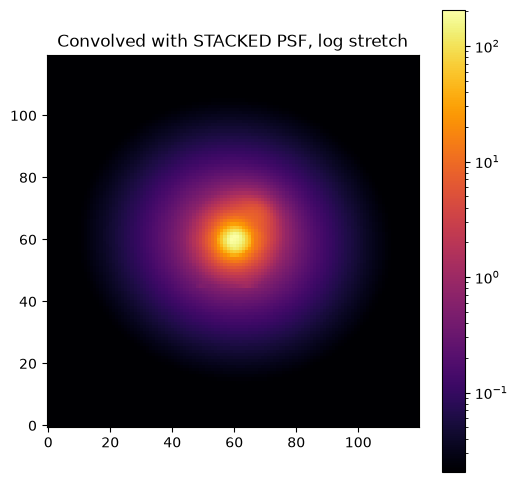

In [31]:
signal_manually_convolved_v2 = convolve_fft(signal_raw, stacked_psf_normalized, normalize_kernel=False)

c = numPix_test // 2
crop_size = 60
signal_cropped_v4 = signal_manually_convolved_v2[c - crop_size:c + crop_size, c - crop_size:c + crop_size]

plt.figure(figsize=(6, 6))
plt.imshow(signal_cropped_v4, cmap='inferno', origin='lower', norm=LogNorm(vmin=signal_cropped_v4.max()*1e-4, vmax=signal_cropped_v4.max()))
plt.colorbar()
plt.title("Convolved with STACKED PSF, log stretch")
plt.show()

In [32]:
import importlib
import psf_matching
importlib.reload(psf_matching)
from psf_matching import build_stacked_psf

test_stacked_psf = build_stacked_psf(image_data, [(363.94, 471.62), (82.07, 73.13), (125.61, 88.97)])

print(np.allclose(test_stacked_psf, stacked_psf_normalized))

True


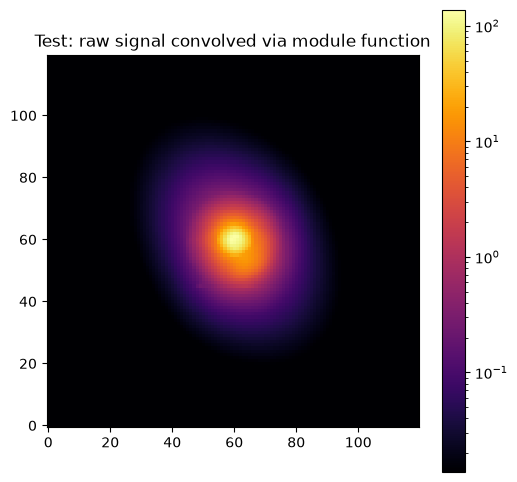

In [33]:
import lens_injector
importlib.reload(lens_injector)
from lens_injector import generate_lens_signal_raw, convolve_with_psf, check_injection_site_clean, normalize_image

result_raw = generate_lens_signal_raw(numPix=numPix_test, pixel_scale=pixel_scale_arcsec, is_lens=True, seed=777)
convolved_signal = convolve_with_psf(result_raw['signal'], stacked_psf_normalized)

c = numPix_test // 2
crop_size = 60
convolved_cropped = convolved_signal[c - crop_size:c + crop_size, c - crop_size:c + crop_size]

plt.figure(figsize=(6, 6))
plt.imshow(convolved_cropped, cmap='inferno', origin='lower', norm=LogNorm(vmin=convolved_cropped.max()*1e-4, vmax=convolved_cropped.max()))
plt.title("Test: raw signal convolved via module function")
plt.colorbar()
plt.show()

In [34]:
background_square = image_data[:numPix_test, :numPix_test]
is_clean = check_injection_site_clean(background_square)
print("Injection site clean:", is_clean)

test_normalized = normalize_image(background_square)
print("Normalized range:", test_normalized.min(), test_normalized.max())

Injection site clean: False
Normalized range: 0.0 1.0


In [35]:
hdul_large = download_hsc_cutout(ra_center=150.106, dec_center=2.22092, size_arcsec=400)
large_background_data = hdul_large[1].data
print(large_background_data.shape)

(2382, 2380)


True


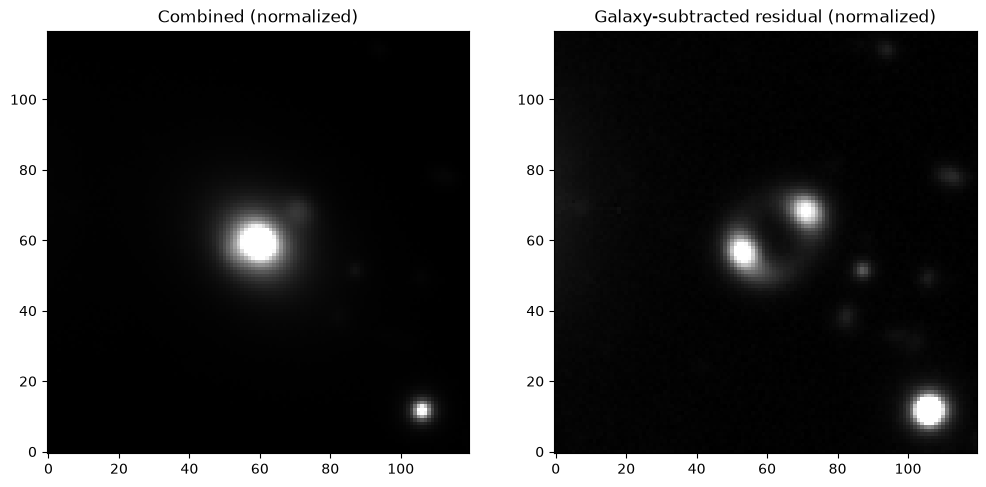

In [36]:
importlib.reload(lens_injector)
from lens_injector import inject_lens_into_background

result_final = inject_lens_into_background(
    large_background_data, pixel_scale=pixel_scale_arcsec, crop_size=120,
    psf_kernel=stacked_psf_normalized, is_lens=True, seed=999
)

print(result_final is not None)
if result_final is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(result_final['image_normalized'], cmap='gray', origin='lower')
    axes[0].set_title("Combined (normalized)")
    axes[1].imshow(result_final['residual_normalized'], cmap='gray', origin='lower')
    axes[1].set_title("Galaxy-subtracted residual (normalized)")
    plt.show()

In [37]:
print("Clean site found:", result_final is not None)

peak_before = result_final['image'].max()
peak_after = result_final['residual'].max()
galaxy_model_peak = convolve_with_psf(
    generate_lens_signal_raw(numPix=120, pixel_scale=pixel_scale_arcsec, seed=999)['galaxy_only_signal'],
    stacked_psf_normalized
).max()

print("Combined image peak:", peak_before)
print("Residual peak:", peak_after)
print("Galaxy-only model peak (what we subtracted):", galaxy_model_peak)
print("Difference (before - after):", peak_before - peak_after)

Clean site found: True
Combined image peak: 37.646391502129475
Residual peak: 21.81746316559687
Galaxy-only model peak (what we subtracted): 37.373448050774215
Difference (before - after): 15.828928336532606


In [38]:
peak_loc_combined = np.unravel_index(np.argmax(result_final['image']), result_final['image'].shape)
peak_loc_residual = np.unravel_index(np.argmax(result_final['residual']), result_final['residual'].shape)
print("Combined image peak location:", peak_loc_combined)
print("Residual peak location:", peak_loc_residual)
print("Expected injection center:", 60, 60)

Combined image peak location: (np.int64(60), np.int64(59))
Residual peak location: (np.int64(12), np.int64(106))
Expected injection center: 60 60


In [39]:
print("Combined value at (60,60):", result_final['image'][60, 60])
print("Residual value at (60,60):", result_final['residual'][60, 60])
print("Galaxy model value at (60,60):", galaxy_model_peak)

Combined value at (60,60): 37.50655673984635
Residual value at (60,60): 0.18535260574979873
Galaxy model value at (60,60): 37.373448050774215


In [41]:
import sys
sys.path.append('../src')
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import importlib

import hsc_downloader
from hsc_downloader import download_hsc_cutout

field_centers = [
    (150.106, 2.22092),
    (150.406, 2.52092),
    (149.806, 1.92092),
]

large_backgrounds = []
for ra, dec in field_centers:
    hdul_f = download_hsc_cutout(ra_center=ra, dec_center=dec, size_arcsec=400)
    large_backgrounds.append(hdul_f[1].data)
    print(ra, dec, hdul_f[1].data.shape)

150.106 2.22092 (2382, 2380)
150.406 2.52092 (2382, 2379)
149.806 1.92092 (2381, 2381)


In [42]:
import psf_matching
importlib.reload(psf_matching)
from psf_matching import find_star_candidates

sources_1, median_1 = find_star_candidates(large_backgrounds[1])
sources_2, median_2 = find_star_candidates(large_backgrounds[2])

print(sources_1[:10])
print(sources_2[:10])

 id      x_centroid         y_centroid     ...    mag        daofind_mag    
---- ------------------ ------------------ ... --------- -------------------
1020  784.2547772674677  843.7272377319349 ...  -9.71042  -8.386159426844891
 442  556.5093062479605  363.2719647098643 ... -9.649751  -8.016467454635311
2665  496.9245444901734  2212.597274130745 ... -9.617031   -7.94019390710622
 244 2187.9515119914563 187.43840324784014 ... -9.463408  -7.869722816872403
2260 1852.6348759810514 1875.6209843218264 ... -9.461949  -8.469253252628405
 289 158.79303009006804 228.64159640819642 ... -9.088903 -7.4978284748511035
1354 1943.7800811793072 1115.1336636831209 ...  -9.00348  -7.448552671623917
1128 1234.2856560615548  931.8017318815045 ... -8.623754  -6.616487767661333
 834 2005.2129137040683  690.8269650100298 ... -8.568857  -7.330577827642417
1081  711.9677522522542   897.789669940859 ... -8.545572  -7.455474576404112
 id      x_centroid         y_centroid     ...    mag         daofind_mag   

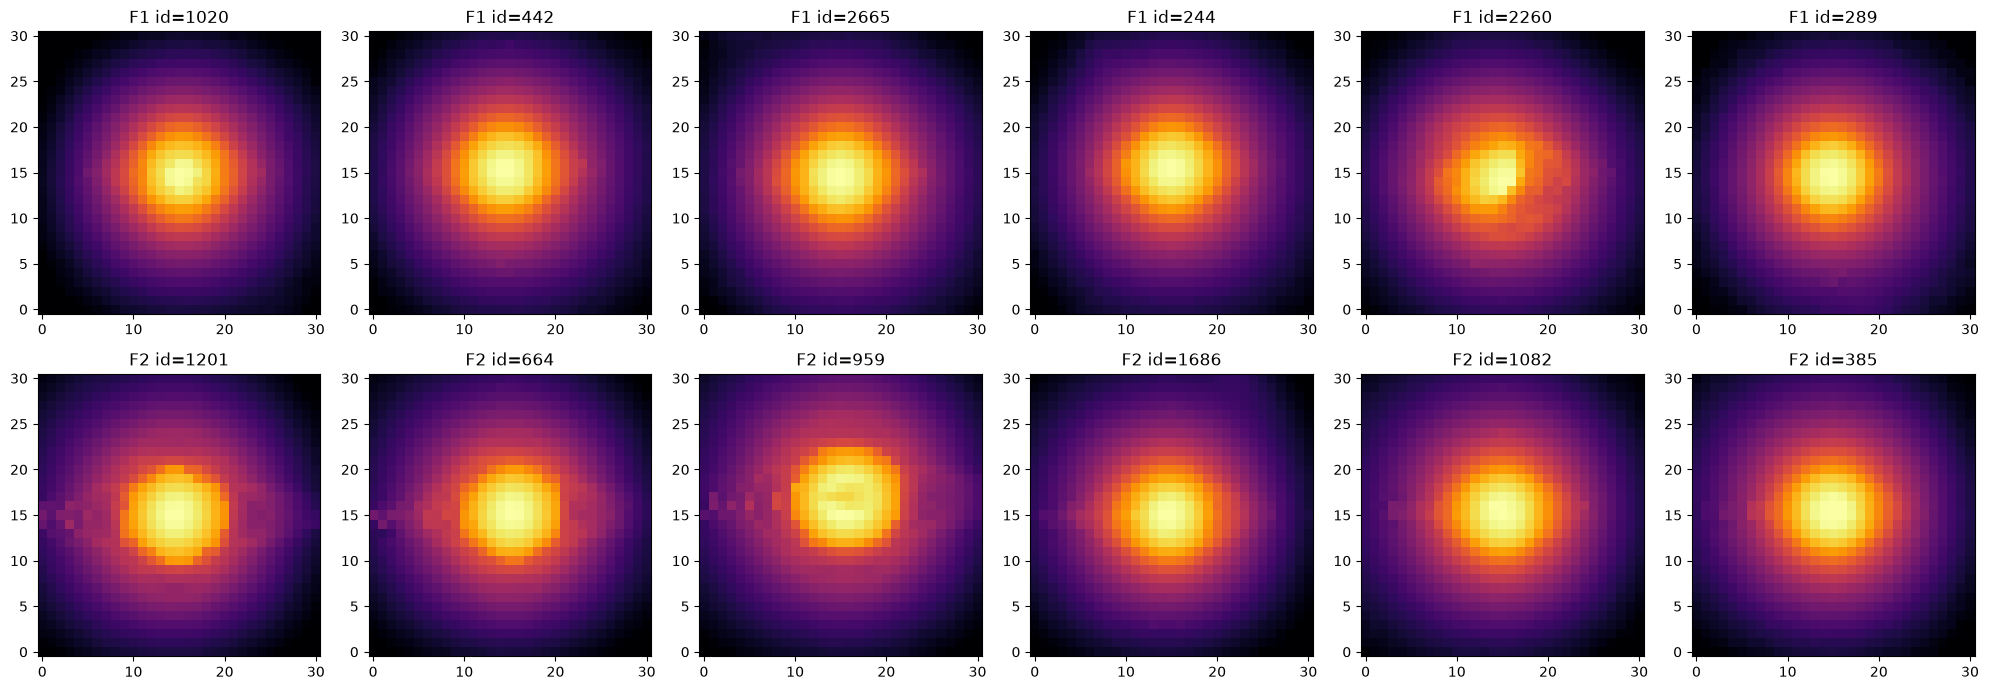

In [43]:
def extract_stamp_odd(image, x_center, y_center, half_size=15):
    x_int, y_int = int(round(x_center)), int(round(y_center))
    return image[y_int - half_size:y_int + half_size + 1, x_int - half_size:x_int + half_size + 1]

candidates_1 = {1020: (784.25, 843.73), 442: (556.51, 363.27), 2665: (496.92, 2212.60),
                244: (2187.95, 187.44), 2260: (1852.63, 1875.62), 289: (158.79, 228.64)}
candidates_2 = {1201: (1049.65, 1358.08), 664: (896.28, 789.26), 959: (1037.49, 1102.46),
                1686: (1348.68, 1944.01), 1082: (344.97, 1230.37), 385: (1478.97, 464.44)}

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for i, (cid, (cx, cy)) in enumerate(candidates_1.items()):
    stamp = extract_stamp_odd(large_backgrounds[1], cx, cy)
    axes[0, i].imshow(stamp, cmap='inferno', origin='lower', norm=LogNorm(vmin=max(stamp.max()*1e-3, 0.01), vmax=stamp.max()))
    axes[0, i].set_title(f"F1 id={cid}")
for i, (cid, (cx, cy)) in enumerate(candidates_2.items()):
    stamp = extract_stamp_odd(large_backgrounds[2], cx, cy)
    axes[1, i].imshow(stamp, cmap='inferno', origin='lower', norm=LogNorm(vmin=max(stamp.max()*1e-3, 0.01), vmax=stamp.max()))
    axes[1, i].set_title(f"F2 id={cid}")
plt.tight_layout()
plt.show()

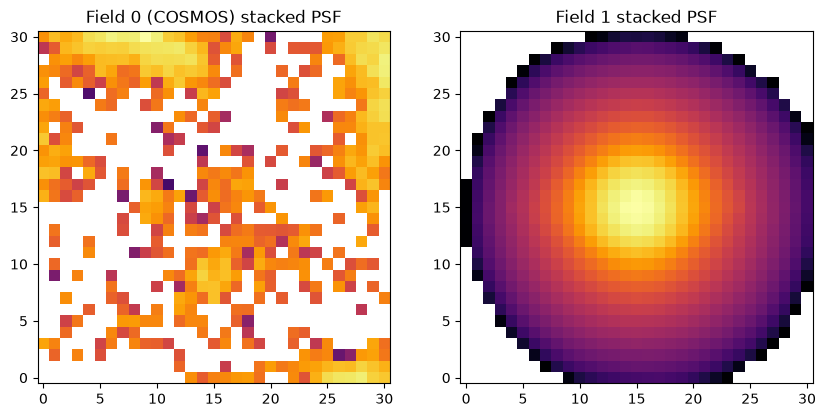

Field 0 sum: 1.0 shape: (31, 31)
Field 1 sum: 1.0 shape: (31, 31)


In [44]:
from psf_matching import build_stacked_psf

psf_field0 = build_stacked_psf(large_backgrounds[0], [(363.94, 471.62), (82.07, 73.13), (125.61, 88.97)])

psf_field1 = build_stacked_psf(large_backgrounds[1], [(784.25, 843.73), (556.51, 363.27), (496.92, 2212.60), (2187.95, 187.44), (158.79, 228.64)])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(psf_field0, cmap='inferno', origin='lower', norm=LogNorm(vmin=psf_field0.max()*1e-4, vmax=psf_field0.max()))
axes[0].set_title("Field 0 (COSMOS) stacked PSF")
axes[1].imshow(psf_field1, cmap='inferno', origin='lower', norm=LogNorm(vmin=psf_field1.max()*1e-4, vmax=psf_field1.max()))
axes[1].set_title("Field 1 stacked PSF")
plt.show()

print("Field 0 sum:", psf_field0.sum(), "shape:", psf_field0.shape)
print("Field 1 sum:", psf_field1.sum(), "shape:", psf_field1.shape)

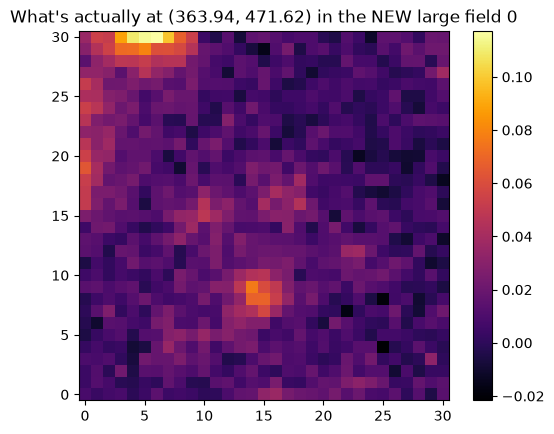

In [45]:
stamp_check = extract_stamp_odd(large_backgrounds[0], 363.94, 471.62)
plt.imshow(stamp_check, cmap='inferno', origin='lower')
plt.title("What's actually at (363.94, 471.62) in the NEW large field 0")
plt.colorbar()
plt.show()

In [46]:
sources_0, median_0 = find_star_candidates(large_backgrounds[0])
print(sources_0[:10])

 id      x_centroid         y_centroid     ...    mag       daofind_mag    
---- ------------------ ------------------ ... --------- ------------------
1344 1540.5201364358222 1060.7896949878195 ... -9.833311 -8.492649737385161
 116 1106.4264849485378  95.99498143182866 ... -9.803072  -8.49098687981876
1670 1231.9421330300443 1340.6234240715123 ... -9.792425  -8.16284329124818
1863 243.60250762902203  1517.361194426863 ... -9.714916 -8.368028073994054
1435  385.1436920096659 1137.7022517512391 ... -9.619142  -8.18886418306543
1575  2110.775177034545 1266.2933629675106 ... -8.996146  -7.48056173081328
 433  992.6014548334732 374.34174575583984 ...  -8.82699 -7.362241894680488
2419 442.22375129120303 2049.7547343232163 ... -8.616819 -7.367149925040177
1194  950.0720336534146  942.1300074476829 ... -8.394991 -7.265735920064995
1483 1411.5600143498116  1173.732628672805 ... -8.306986 -7.122343395030244


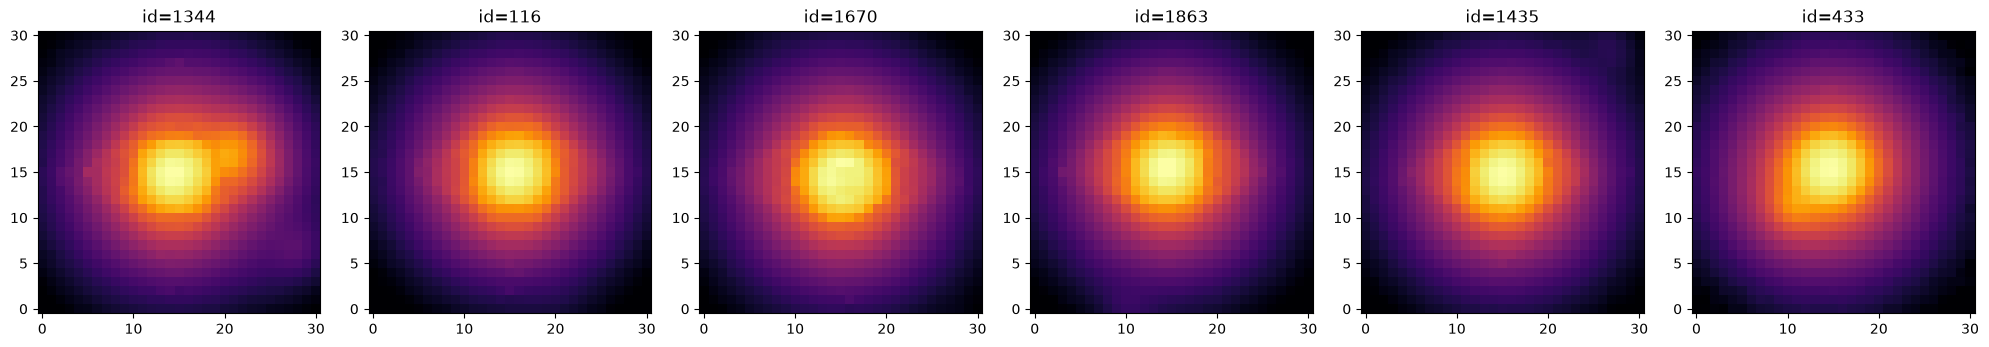

In [47]:
candidates_0 = {1344: (1540.52, 1060.79), 116: (1106.43, 95.99), 1670: (1231.94, 1340.62),
                1863: (243.60, 1517.36), 1435: (385.14, 1137.70), 433: (992.60, 374.34)}

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
for i, (cid, (cx, cy)) in enumerate(candidates_0.items()):
    stamp = extract_stamp_odd(large_backgrounds[0], cx, cy)
    axes[i].imshow(stamp, cmap='inferno', origin='lower', norm=LogNorm(vmin=max(stamp.max()*1e-3, 0.01), vmax=stamp.max()))
    axes[i].set_title(f"id={cid}")
plt.tight_layout()
plt.show()

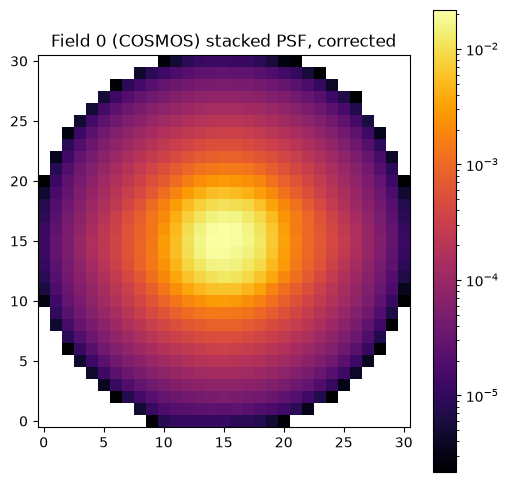

Sum: 1.0 Edge maxes: 1.1288120053666372e-05 1.2625920904281712e-05


In [48]:
psf_field0_v2 = build_stacked_psf(large_backgrounds[0], [(1106.43, 95.99), (1231.94, 1340.62), (243.60, 1517.36), (385.14, 1137.70), (992.60, 374.34)])

plt.figure(figsize=(6, 6))
plt.imshow(psf_field0_v2, cmap='inferno', origin='lower', norm=LogNorm(vmin=psf_field0_v2.max()*1e-4, vmax=psf_field0_v2.max()))
plt.title("Field 0 (COSMOS) stacked PSF, corrected")
plt.colorbar()
plt.show()

print("Sum:", psf_field0_v2.sum(), "Edge maxes:", psf_field0_v2[0,:].max(), psf_field0_v2[-1,:].max())

In [49]:
import time

start = time.time()
for _ in range(10):
    _ = inject_lens_into_background(large_backgrounds[0], pixel_scale=pixel_scale_arcsec,
                                       crop_size=120, psf_kernel=psf_field0_v2, is_lens=True)
elapsed = time.time() - start
print(f"10 injections took {elapsed:.2f}s, ~{elapsed/10:.3f}s per image")

10 injections took 0.35s, ~0.035s per image


In [50]:
importlib.reload(lens_injector)
from lens_injector import generate_injected_dataset

h5_path_inj, parquet_path_inj = generate_injected_dataset(
    n_lens=5, n_nonlens=5, large_backgrounds=large_backgrounds[:2], psf_kernels=[psf_field0_v2, psf_field1],
    crop_size=120, pixel_scale=pixel_scale_arcsec, output_dir='../data/processed/injected_test', seed_start=5000
)

Generating injected images: 100%|██████████| 10/10 [00:00<00:00, 37.64it/s]


Saved 10 images to ../data/processed/injected_test/injected_dataset.h5
Saved metadata (10 rows) to ../data/processed/injected_test/injected_dataset_metadata.parquet
Label distribution:
label
1    5
0    5
Name: count, dtype: int64


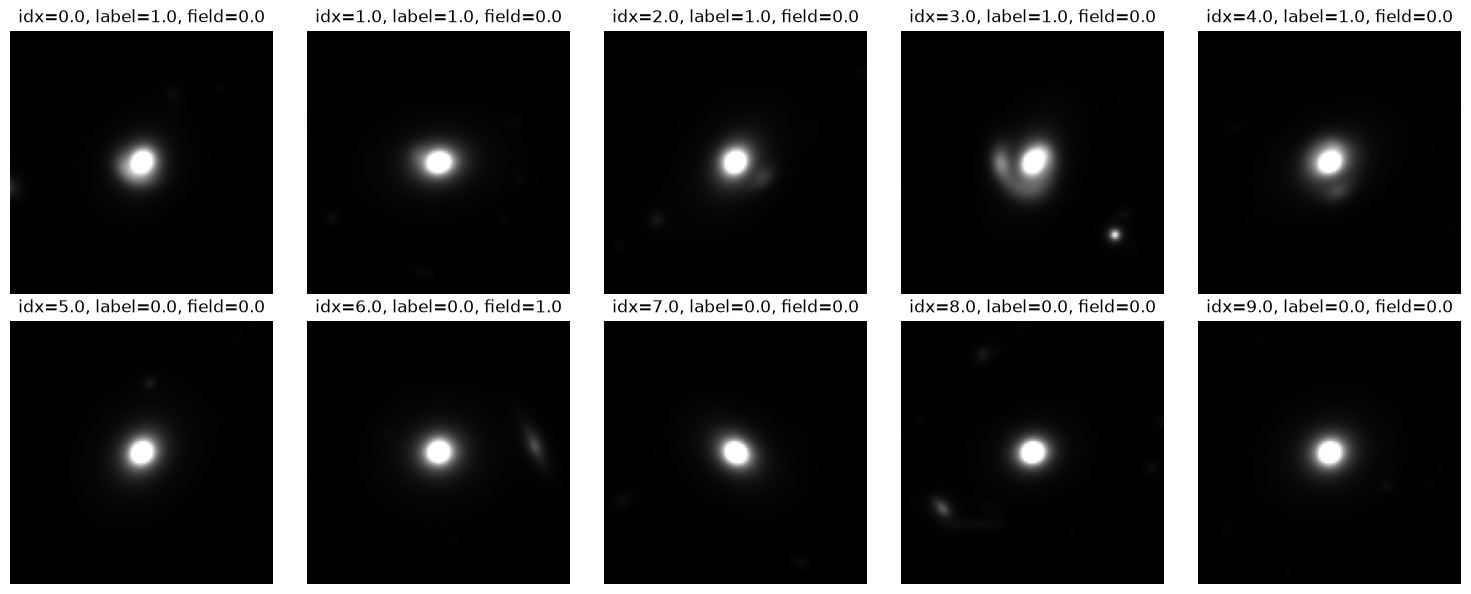

In [54]:
import h5py
with h5py.File(h5_path_inj, 'r') as f:
    loaded_images = f['images'][:]
    loaded_residuals = f['residuals'][:]
loaded_metadata = pd.read_parquet(parquet_path_inj)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(loaded_images[i], cmap='gray', origin='lower')
    ax.set_title(f"idx={loaded_metadata.iloc[i]['index']}, label={loaded_metadata.iloc[i]['label']}, field={loaded_metadata.iloc[i]['field_idx']}")
    ax.axis('off')
plt.tight_layout()
plt.show()